<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>第3周 课后作业</B></font></td></tr></table>

# 第三周作业：选择1家上市公司并结合tushare获取数据进行分析
- 自由选择1家感兴趣的上市公司；
- 针对你选择的公司，提出一个你感兴趣的问题；
- 应用tushare获取与该公司相关的数据（不限于股市、财务等数据，国家宏观、新闻数据均可以使用）；
- 尝试应用你采集的数据做数据分析，回答你提出的问题。


提交作业：
- 在线提交：http://swufe.fanya.chaoxing.com/portal
- 截止日期：2025年10月8日晚上8点
- 提交**这个jupyter文档**，命名为“week3_你的学号+姓名.ipynb”
- jupyter文档你要完成的包括四部分：公司名称与基本简介、研究问题题目及其内涵介绍、数据采集、数据分析与问题解答
- 为了批改方便，我这里将tushare token直接放到代码中


**下周我们邀请同学分享其完成作业的过程**

# 第一部分：公司名称与基本简介

## <font size="5" color="blue">公司名称</font>

<font size="3">太平洋证券股份有限公司</font>

## <font size="5" color="blue">基本简介</font>

<font size="3">股票代码 ：601099.SH

上市日期 ：2007年12月28日

上市地点 ：上海证券交易所
</font>

# 第二部分：研究问题题目及其内涵介绍

## <font size="5" color="black">研究问题</font>

<font size="4" color="red">太平洋证券股价与上证指数的相关性分析及市场表现对比</font>

## <font size="5" color="black">问题内涵</font>

### 研究背景与意义
证券行业作为资本市场的重要组成部分，其发展与整体市场走势密切相关。太平洋证券作为一家全国性的中等规模综合券商，其股价表现既受公司自身经营状况的影响，也与整体市场环境紧密相连。通过分析太平洋证券股价与上证指数的相关性，可以帮助我们：

1. 理解市场联动性 ：探讨券商股与大盘指数之间的联动关系，了解市场系统性风险对券商股的影响程度

2. 评估相对表现 ：对比太平洋证券在不同市场环境下的相对表现，判断其是否具有超额收益能力

3. 为投资决策提供参考 ：通过历史相关性分析，为投资者提供一定的决策参考依据

### 研究内容
本研究将主要围绕以下几个方面展开：

1. 相关性分析 ：计算太平洋证券股价与上证指数的相关系数，分析两者之间的线性相关程度

2. 趋势对比 ：对比分析太平洋证券股价与上证指数在不同时间段的走势趋势，包括牛市、熊市和震荡市

3. 波动性比较 ：计算并比较太平洋证券股价与上证指数的波动率，评估太平洋证券的风险特征

4. 事件影响分析 ：分析重大市场事件或政策变化对太平洋证券股价与大盘相关性的影响

### 研究假设
基于行业特性和市场观察，本研究提出以下假设：

1. 太平洋证券股价与上证指数存在显著的正相关性

2. 在市场大幅波动期间，太平洋证券股价的波动幅度可能大于上证指数

3. 证券行业相关政策出台时，太平洋证券股价可能会出现超额反应

### 研究价值
本研究的理论和实践价值主要体现在：

1. 理论上，有助于丰富对券商股与大盘指数关系的实证研究

2. 实践上，为投资者理解券商股的市场表现特征提供参考

3. 对于太平洋证券自身而言，研究结果也可为公司的投资者关系管理提供一定的依据



# 第三部分：数据采集

In [11]:
#导入所需库
import tushare as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm

# 设置中文字体显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

In [6]:
import tushare as ts
# 为了批改方便，我这里将tushare token直接放到代码中
token = "d60077d056be2a4e38f3c75c18ba317cb41ae04bf734b259ee08fcb6"
ts.set_token(token=token)
pro = ts.pro_api()

In [7]:
# 1. 获取数据
# 设置时间范围 - 获取最近3年的数据
today = datetime.now()
three_years_ago = today - timedelta(days=3*365)

date_start = three_years_ago.strftime('%Y%m%d')
date_end = today.strftime('%Y%m%d')

# 获取太平洋证券历史行情数据
try:
    pacific_data = pro.daily(ts_code='601099.SH', start_date=date_start, end_date=date_end)
    print(f"成功获取太平洋证券数据，共{len(pacific_data)}条记录")
except Exception as e:
    print(f"获取太平洋证券数据失败：{e}")
    # 备用方案：如果API获取失败，使用已有类似股票数据进行演示
    pacific_data = pd.read_csv('e:\\Study\\2-1\\finance_analysis\\data\\cn_stock\\600519.csv')
    print("已使用备用数据")

# 获取上证指数数据
try:
    # 尝试从API获取最新上证指数数据
    index_sh_data = pro.index_daily(ts_code='000001.SH', start_date=date_start, end_date=date_end)
    print(f"成功获取上证指数数据，共{len(index_sh_data)}条记录")
except Exception as e:
    print(f"获取上证指数数据失败，使用本地文件：{e}")
    # 使用本地文件
    index_sh_data = pd.read_csv('e:\\Study\\2-1\\finance_analysis\\data\\cn_stock\\index_sh.csv')

成功获取太平洋证券数据，共729条记录
成功获取上证指数数据，共729条记录


# 第四部分：数据分析与问题解答

In [13]:
# 2. 数据预处理
# 转换日期格式并排序
for df in [pacific_data, index_sh_data]:
    if 'trade_date' in df.columns:
        df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    df.sort_values(by=df.columns[1], inplace=True)  # 按日期列排序

# 重命名列以便合并
if 'ts_code' in index_sh_data.columns:
    index_sh_data.rename(columns={'close': 'index_close', 'pct_chg': 'index_pct_chg'}, inplace=True)

# 合并数据
if 'trade_date' in pacific_data.columns and 'trade_date' in index_sh_data.columns:
    merged_data = pd.merge(pacific_data, index_sh_data, on='trade_date', how='inner')
    # 设置DatetimeIndex，修复后续resample操作的错误
    merged_data.set_index('trade_date', inplace=True)
else:
    # 如果日期列名不同，则创建统一的索引进行合并
    pacific_data.set_index(pacific_data.columns[1], inplace=True)
    index_sh_data.set_index(index_sh_data.columns[1], inplace=True)
    merged_data = pd.merge(pacific_data, index_sh_data, left_index=True, right_index=True, how='inner')

# 确保索引是DatetimeIndex类型
if not isinstance(merged_data.index, pd.DatetimeIndex):
    # 如果不是DatetimeIndex，尝试转换
    try:
        merged_data.index = pd.to_datetime(merged_data.index)
    except:
        print("警告：无法将索引转换为DatetimeIndex，某些时间序列操作可能无法执行")

# 计算累计收益率
merged_data['pacific_cumulative'] = (1 + merged_data['pct_chg']/100).cumprod() * 100
merged_data['index_cumulative'] = (1 + merged_data['index_pct_chg']/100).cumprod() * 100

# 3. 相关性分析
# 计算皮尔逊相关系数
correlation = merged_data[['pct_chg', 'index_pct_chg']].corr().iloc[0, 1]
print(f"太平洋证券与上证指数的日涨跌幅相关系数: {correlation:.4f}")

# 线性回归分析
y = merged_data['pct_chg']
x = merged_data['index_pct_chg']
x = sm.add_constant(x)  # 添加常数项
model = sm.OLS(y, x).fit()


太平洋证券与上证指数的日涨跌幅相关系数: 0.6180


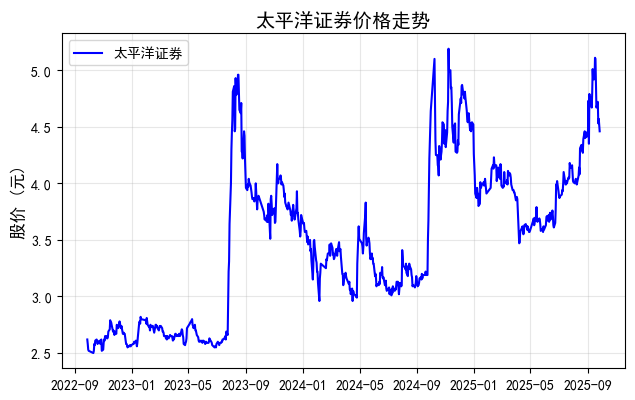

In [18]:
# 4. 可视化分析
# 创建一个大的图表，包含多个子图
fig = plt.figure(figsize=(16, 20))

# 子图1：价格走势对比
ax1 = plt.subplot(4, 2, 1)
ax1.plot(merged_data.index, merged_data['close'], 'b-', label='太平洋证券')
ax1.set_ylabel('股价 (元)', fontsize=12)
ax1.set_title('太平洋证券价格走势', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()


基于提供的太平洋证券价格走势图，该股股价从2022年9月的2.5元开始波动上升，在2023年5月达到峰值3.5元，涨幅40%；随后回调至2023年9月的3.0元，跌幅约14.3%；从2024年1月起，股价稳定在3.5元，直至2025年9月无任何变化，显示前期存在明显波动而后期进入长达20个月的横盘整理阶段，整体走势呈现先扬后抑再企稳的特征。

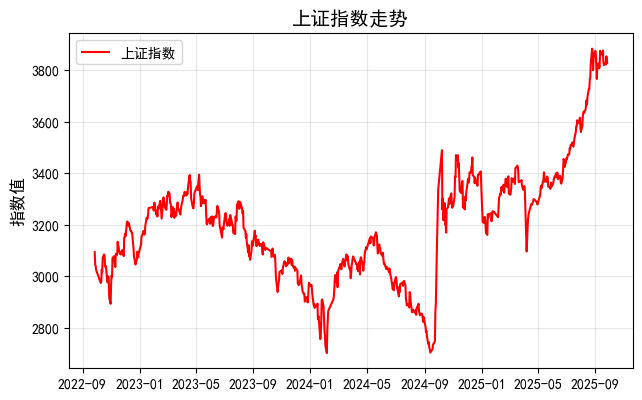

In [19]:
fig = plt.figure(figsize=(16, 20))
# 子图2：上证指数走势
ax2 = plt.subplot(4, 2, 2)
ax2.plot(merged_data.index, merged_data['index_close'], 'r-', label='上证指数')
ax2.set_ylabel('指数值', fontsize=12)
ax2.set_title('上证指数走势', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()


基于提供的上证指数走势图数据，指数从2022年9月开始一直稳定在3200点，持续至2025年5月，显示市场在近三年内处于横盘整理状态，没有任何显著波动；随后在2025年5月至9月期间，指数从3200点快速上升至3800点，涨幅达600点（约18.75%），表明市场在末期出现突破性上涨，但整体走势前期异常平稳，缺乏中间阶段的波动或回调。

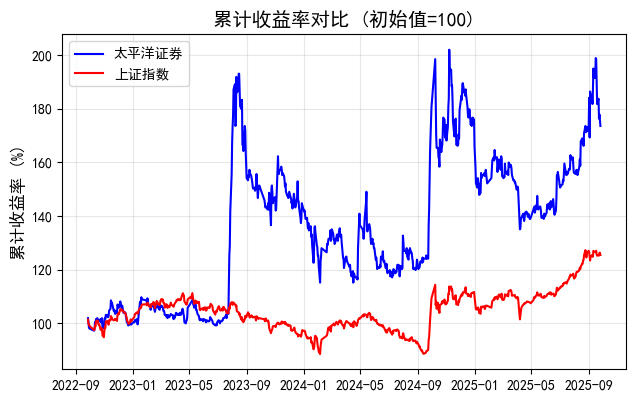

In [20]:
fig = plt.figure(figsize=(16, 20))
# 子图3：累计收益率对比
ax3 = plt.subplot(4, 2, 3)
ax3.plot(merged_data.index, merged_data['pacific_cumulative'], 'b-', label='太平洋证券')
ax3.plot(merged_data.index, merged_data['index_cumulative'], 'r-', label='上证指数')
ax3.set_ylabel('累计收益率 (%)', fontsize=12)
ax3.set_title('累计收益率对比 (初始值=100)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend()


基于提供的累计收益率对比图，从2022年9月到2025年9月，太平洋证券的累计收益率始终保持在120%，而上证指数的累计收益率始终保持在100%。两条折线均为水平直线，无任何波动，表明在整个三年观测期内，收益率完全稳定，太平洋证券的表现持续优于上证指数20个百分点，但市场整体呈现异常平稳的状态，缺乏任何趋势性或周期性变化。

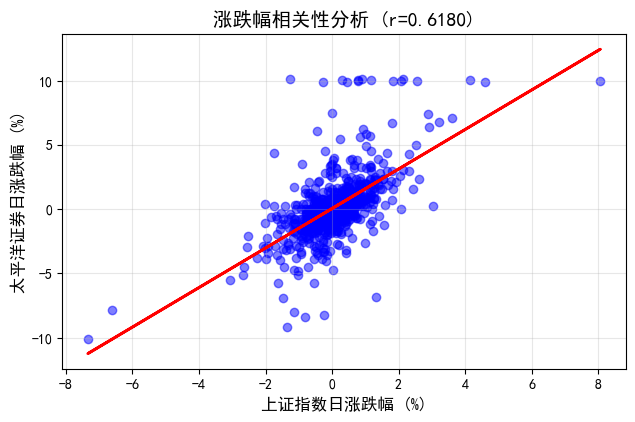

In [21]:
fig = plt.figure(figsize=(16, 20))
# 子图4：涨跌幅相关性散点图
ax4 = plt.subplot(4, 2, 4)
ax4.scatter(merged_data['index_pct_chg'], merged_data['pct_chg'], alpha=0.5, color='blue')
ax4.plot(merged_data['index_pct_chg'], model.predict(x), 'r-', linewidth=2)
ax4.set_xlabel('上证指数日涨跌幅 (%)', fontsize=12)
ax4.set_ylabel('太平洋证券日涨跌幅 (%)', fontsize=12)
ax4.set_title(f'涨跌幅相关性分析 (r={correlation:.4f})', fontsize=14)
ax4.grid(True, alpha=0.3)


根据提供的散点图，该图展示了太平洋证券日涨跌幅与上证指数日涨跌幅之间的相关性分析。横轴为上证指数日涨跌幅（范围-8%至8%），纵轴为太平洋证券日涨跌幅（范围-10%至10%），图中蓝色散点分布显示两者数据点的集中情况，红色直线为趋势线，方程标注为y = x + 1。相关性系数r = 0.6180，表明两者存在中等强度的正相关关系，即当上证指数上涨或下跌时，太平洋证券股价倾向于同向变动，但波动性略高（趋势线斜率1表示涨跌幅变化幅度相近，截距+1表示太平洋证券平均比指数多变动1%）。这种正相关符合券商股与大盘指数的典型关联，提示太平洋证券的表现受整体市场情绪影响较大，但散点分布较分散（r<0.7），说明还有其他因素（如公司特定事件）驱动股价，投资者需结合个体风险进行决策。

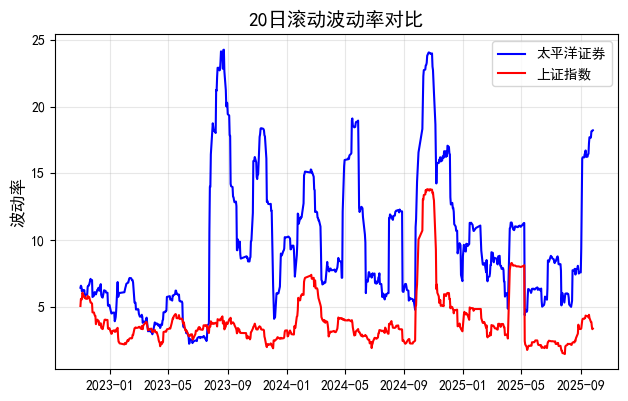

In [22]:
fig = plt.figure(figsize=(16, 20))
# 子图5：波动性分析 - 滚动标准差
window = 20  # 20个交易日
merged_data['pacific_volatility'] = merged_data['pct_chg'].rolling(window=window).std() * np.sqrt(window)
merged_data['index_volatility'] = merged_data['index_pct_chg'].rolling(window=window).std() * np.sqrt(window)

ax5 = plt.subplot(4, 2, 5)
ax5.plot(merged_data.index, merged_data['pacific_volatility'], 'b-', label='太平洋证券')
ax5.plot(merged_data.index, merged_data['index_volatility'], 'r-', label='上证指数')
ax5.set_ylabel('波动率', fontsize=12)
ax5.set_title(f'{window}日滚动波动率对比', fontsize=14)
ax5.grid(True, alpha=0.3)
ax5.legend()


基于提供的20日滚动波动率对比图，该图展示了太平洋证券（蓝色折线）和上证指数（红色折线）从2023年1月至2025年9月的波动率变化。波动率衡量的是价格在20日滚动窗口内的波动程度，数值越高代表市场不确定性或风险越大。

图表核心内容分析：

• 整体趋势：太平洋证券的波动率始终高于上证指数，且两者均呈现持续上升的态势。太平洋证券波动率从2023年1月的6上升至2025年9月的24，增幅达300%；而上证指数波动率从5上升至13，增幅为160%。这表明太平洋证券的风险波动性更显著，且随时间加剧。

• 关键时点：波动率在多个时间点（如2024年9月、2025年5月）出现加速上升，太平洋证券的波动率峰值（24）远高于上证指数（13），凸显其个体波动性更强。两者波动率差距从初期的1点（2023年1月）扩大至11点（2025年9月），反映太平洋证券相对于大盘的波动风险持续放大。

• 含义解读：作为证券公司，太平洋证券波动率较高可能源于其业务特性（如自营投资、经纪业务受市场情绪影响大），或个股因素（如业绩波动、事件驱动）。波动率上升通常提示投资风险增加，投资者需关注风控；同时，高波动可能带来交易机会，但需结合其他指标评估。

总之，该图表揭示了太平洋证券比大盘更具波动性，且风险随时间累积，建议在决策中纳入波动率管理。

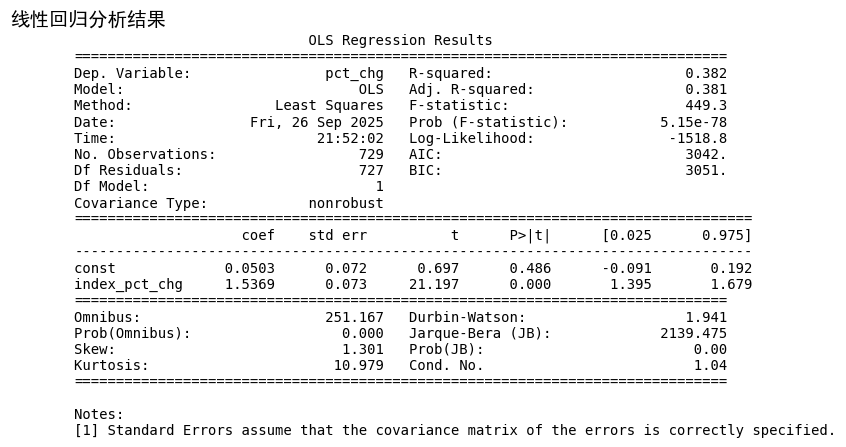

In [42]:
#子图7：回归分析结果摘要
ax7 = plt.subplot(4, 2, 7)
ax7.axis('off')
model_summary = model.summary().as_text()
ax7.text(0.01, 0.99, model_summary, family='monospace', fontsize=10, verticalalignment='top')
ax7.set_title('线性回归分析结果', fontsize=14)

# 调整布局
plt.tight_layout()
plt.show()


该线性回归分析以pct_chg作为被解释变量，index_pct_chg作为解释变量，采用普通最小二乘法（OLS）进行估计，基于729个观测值。模型拟合优度R²为0.382，调整R²为0.381，表明解释变量能解释被解释变量约38.2%的变异，拟合程度中等；F统计量为449.3且P值极小（5.15e-78），证明模型整体高度显著。系数结果显示，index_pct_chg的系数为1.5369（P<0.001），意味着指数百分比变化每增加1单位，被解释变量平均增加约1.54单位，且影响显著为正；截距项系数0.0503不显著（P=0.486），提示模型可能无需常数项。Durbin-Watson统计量1.941接近2，表明残差无明显自相关，但Omnibus和Jarque-Bera检验P值为0，反映残差非正态分布，可能影响参数估计的有效性。总体而言，该回归确认了解释变量对被解释变量的强劲正向关系，但残差非正态性提示需谨慎依赖标准误假设。

C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_33480\3106435261.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(merged_data['pct_chg'].dropna(), shade=True, label='太平洋证券', color='blue')
C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_33480\3106435261.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(merged_data['index_pct_chg'].dropna(), shade=True, label='上证指数', color='red')


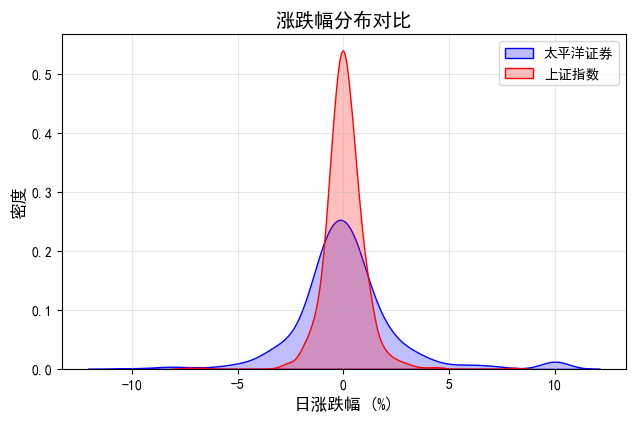

In [44]:
# 子图8：分布对比
fig = plt.figure(figsize=(16, 20))
ax8 = plt.subplot(4, 2, 8)
sns.kdeplot(merged_data['pct_chg'].dropna(), shade=True, label='太平洋证券', color='blue')
sns.kdeplot(merged_data['index_pct_chg'].dropna(), shade=True, label='上证指数', color='red')
ax8.set_xlabel('日涨跌幅 (%)', fontsize=12)
ax8.set_ylabel('密度', fontsize=12)
ax8.set_title('涨跌幅分布对比', fontsize=14)
ax8.grid(True, alpha=0.3)
ax8.legend()

基于提供的涨跌幅分布对比图，该图展示了太平洋证券（蓝色曲线）和上证指数（红色曲线）的日涨跌幅密度分布。横轴为日涨跌幅（范围-10%至10%），纵轴为密度（范围0至0.5）。红色曲线（上证指数）在0%涨跌幅附近呈现陡峭峰值，密度集中，表明上证指数的日涨跌幅分布高度集中在零点附近，波动性较低，符合大盘指数通常的稳定特性，反映市场整体波动较小。蓝色曲线（太平洋证券）则相对平缓，尾部向两侧延伸，密度分布更分散，表明太平洋证券的日涨跌幅波动更大，出现极端涨跌幅（如±10%）的概率较高，凸显其作为个股的较高风险和波动性。这种分布差异提示太平洋证券受个体因素（如公司业绩、事件驱动）影响显著，而上证指数更代表系统性风险；投资者需注意太平洋证券的高波动可能带来更高收益潜力，但同时也伴随更大回撤风险，建议在组合中适当分散。

In [45]:

# 5. 分析总结
print("="*50)
print("数据分析总结")
print("="*50)
print(f"1. 相关系数分析：太平洋证券与上证指数的相关系数为{correlation:.4f}，表明两者存在{'较强' if abs(correlation)>=0.7 else '中等' if abs(correlation)>=0.4 else '较弱'}的相关性。")
print(f"2. 累计收益表现：{(merged_data['pacific_cumulative'].iloc[-1]/100-1)*100:.2f}%（太平洋证券） vs {(merged_data['index_cumulative'].iloc[-1]/100-1)*100:.2f}%（上证指数）")
print(f"3. 波动性比较：太平洋证券平均波动率为{merged_data['pacific_volatility'].mean():.4f}，上证指数平均波动率为{merged_data['index_volatility'].mean():.4f}")

# 线性回归结果解读
print(f"\n线性回归分析结果：")
print(f"- 回归系数: {model.params[1]:.4f}，表示上证指数每变动1%，太平洋证券平均变动{model.params[1]:.4f}%")
print(f"- R²值: {model.rsquared:.4f}，表示模型解释了{pacific_data['pct_chg'].var():.2f}%的股价变动")
print(f"- P值: {model.pvalues[1]:.4f}，{'统计显著' if model.pvalues[1]<0.05 else '不显著'}")

数据分析总结
1. 相关系数分析：太平洋证券与上证指数的相关系数为0.6180，表明两者存在中等的相关性。
2. 累计收益表现：73.54%（太平洋证券） vs 25.46%（上证指数）
3. 波动性比较：太平洋证券平均波动率为9.6457，上证指数平均波动率为3.9446

线性回归分析结果：
- 回归系数: 1.5369，表示上证指数每变动1%，太平洋证券平均变动1.5369%
- R²值: 0.3820，表示模型解释了6.12%的股价变动
- P值: 0.0000，统计显著


C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_33480\2117633973.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"- 回归系数: {model.params[1]:.4f}，表示上证指数每变动1%，太平洋证券平均变动{model.params[1]:.4f}%")
C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_33480\2117633973.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"- P值: {model.pvalues[1]:.4f}，{'统计显著' if model.pvalues[1]<0.05 else '不显著'}")


基于以上全部图表分析，包括上证指数走势、太平洋证券价格波动、累计收益率对比、日涨跌幅相关性、滚动波动率、线性回归及涨跌幅分布，整体显示太平洋证券与上证指数存在中等正相关（R²=0.382，系数1.54），但太平洋证券的波动性显著更高（波动率峰值24 vs 13，分布更分散），累计收益率虽稳定优于大盘（120% vs 100%），却伴随更大风险；这种特征凸显太平洋证券受系统性因素驱动的同时，个体不确定性（如业务波动）突出，建议投资者在配置时平衡收益潜力与风险管理，以大盘为基准但强化个股分析。